In [142]:
import pandas as pd
import re
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent.resolve()))
from src.paths import *
import numpy as np

In [143]:
df = pd.read_excel(VALIDATION_SAMPLE)

## Technologies

In [144]:
def find_language_robust(tags_text, target_languages):
    """
    Check if any target language is present in the tags string using a robust
    regex that handles special characters like '+' and '#'.

    Returns the matched language (original capitalization) or 'n/a' if none found.
    """
    if pd.isna(tags_text) or not tags_text.strip():
        return 'n/a'

    tags_text_lower = tags_text.lower()

    for lang in target_languages:
        lang_lower = lang.lower()
        lang_escaped = re.escape(lang_lower)

        regex_search = r'(^|,\s*)' + lang_escaped + r'(\s*,|$)'

        if re.search(regex_search, tags_text_lower):
            return lang

    return 'n/a'


LANGUAGES = ['Python', 'JavaScript', 'Java', 'PHP', 'C++', 'C#', 'C', 'Obj-C', 'Go',
              'Perl', 'Ruby', 'Delphi', 'Powershell', 'SQL', 'TSQL', 'Vbnet', 'Lisp', 'Lua', 'Bash',
              'R', 'Haskell', 'Matlab', 'Rust']
LOWERCASE_LANGUAGES = [lang.lower() for lang in LANGUAGES]

# Apply language detection
df['language'] = df['technologies'].str.lower().apply(lambda x: find_language_robust(x, LANGUAGES))

In [145]:
language_percentages = df['language'].value_counts() / df.shape[0] * 100
language_percentages

language
n/a           58.028169
Java           9.014085
PHP            7.605634
Python         7.605634
C#             6.197183
C++            3.661972
Bash           1.408451
C              1.408451
Rust           0.845070
JavaScript     0.845070
Ruby           0.845070
Go             0.563380
SQL            0.563380
Lua            0.281690
Matlab         0.281690
Haskell        0.281690
R              0.281690
Powershell     0.281690
Name: count, dtype: float64

In [146]:
language_percentages = language_percentages.drop('n/a', errors='ignore')

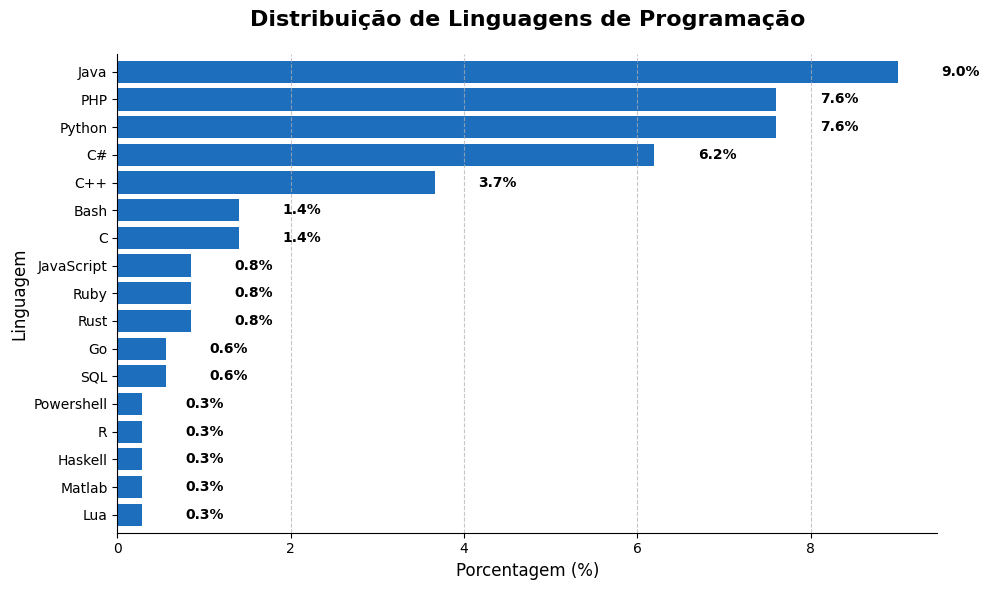

In [ ]:
import matplotlib.pyplot as plt

language_percentages = language_percentages.sort_values(ascending=True)

plt.figure(figsize=(10, 6))

ax = language_percentages.plot.barh(color="#1e6ebe", width=0.8)

plt.title('Distribuição de Linguagens de Programação', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Porcentagem (%)', fontsize=12)
plt.ylabel('Linguagem', fontsize=12)

for i, v in enumerate(language_percentages):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10, fontweight='bold')

ax.spines['top'].set_visible(False)   
ax.spines['right'].set_visible(False) 
ax.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

In [ ]:
def remove_languages_from_technologies(tech_string, languages_to_remove):
    """
    Remove the specified languages from the technologies string.
    Returns 'n/a' if the resulting list is empty or input is missing.
    """
    if pd.isna(tech_string) or not tech_string.strip():
        return 'n/a'
    
    tech_list = [tech.strip() for tech in tech_string.split(',')]
    filtered_list = [tech for tech in tech_list if tech.lower() not in [lang.lower() for lang in languages_to_remove]]
    
    return ', '.join(filtered_list) if filtered_list else 'n/a'


# Apply language removal to create a cleaned technologies column
df['technologies_clean'] = df['technologies'].apply(lambda x: remove_languages_from_technologies(x, LANGUAGES))

In [ ]:
def normalize_technology_terms(cell: str) -> str:
    """Normalize technology terms to canonical short forms."""
    if not isinstance(cell, str):
        return cell

    normalization_map = {
        "aes-128": "aes",
        "aes-256": "aes",
        "rijndael": "aes",
        "aes-ni": "aes",

        "pkcs1": "pkcs",
        "pkcs#1": "pkcs",
        "pkcs5": "pkcs",
        "pkcs#5": "pkcs",
        "pkcs7": "pkcs",
        "pkcs#7": "pkcs",
        "pkcs11": "pkcs",
        "pkcs11.net": "pkcs",
        "pkcs11interop": "pkcs",
        "pkcs12": "pkcs",
        "pkcs#12": "pkcs",

        "sha1": "sha1",
        "sha-1": "sha1",
        "sha256": "sha",
        "sha-256": "sha",
        "sha512": "sha",
        "sha-512": "sha",
        "sha2": "sha",
    }

    normalized_terms = []

    for term in cell.split(","):
        t = term.strip().lower()
        t = re.sub(r"\s+", " ", t)
        normalized_terms.append(normalization_map.get(t, t))

    return ", ".join(normalized_terms)


# Apply normalization to cleaned technologies
df['technologies_clean'] = df['technologies_clean'].apply(normalize_technology_terms)

In [150]:
exploded = (
    df['technologies_clean']
        .str.split(',')
        .explode()
        .str.strip()
        .str.replace('\xa0', '', regex=False)
        .str.lower()
        .replace('', pd.NA)
        .dropna()
)
clean_word_counts = exploded.value_counts()

In [151]:
pd.set_option('display.max_rows', None)
clean_word_counts / df.shape[0] * 100

technologies_clean
openssl                      20.281690
aes                          16.056338
sha                          13.521127
md5                          10.704225
rsa                          10.140845
ssl                           8.169014
n/a                           7.887324
pkcs                          5.915493
.net                          5.352113
hash                          4.225352
base64                        4.225352
iv                            3.943662
sha1                          3.943662
tls                           3.661972
xor                           3.380282
cbc                           3.098592
bcrypt                        2.816901
pgp                           2.535211
mysql                         1.690141
ctr                           1.408451
bouncycastle                  1.408451
ssh                           1.408451
ecb                           1.408451
pbkdf                         1.408451
mac                           1.126761
dicewa

## Tecnologies along topics

In [152]:
tmp_df = df[['topic', 'technologies_clean']].copy()
tmp_df['post_id'] = tmp_df.index
tmp_df = tmp_df.dropna(subset=['topic', 'technologies_clean'])
tmp_df = tmp_df.assign(tech=tmp_df['technologies_clean'].str.split(',')).explode('tech')
tmp_df['tech'] = tmp_df['tech'].astype(str).str.strip().str.lower()
tmp_df = tmp_df[~tmp_df['tech'].isin(['', 'n/a', 'na', 'none'])]

posts_per_topic = df.groupby('topic').size().to_dict()
tech_topic_counts = tmp_df.groupby(['tech', 'topic'])['post_id'].nunique().reset_index()
tech_topic_counts.columns = ['tech', 'topic', 'count']

tech_topic_counts['pct'] = tech_topic_counts.apply(
    lambda row: (row['count'] / posts_per_topic.get(row['topic'], 1)) * 100, 
    axis=1
)

tech_topic_counts = tech_topic_counts.sort_values(by=['tech', 'pct'], ascending=[True, False])

def format_row(row):
    return f'({row["pct"]:.2f}%) "{row["topic"][:16]}..."'

tech_topic_counts['topic_formatted'] = tech_topic_counts.apply(format_row, axis=1)

final_table = (
    tech_topic_counts
    .groupby('tech')['topic_formatted']
    .apply(lambda x: ", ".join(x))
    .reset_index()
)

print(f"{'TECHNOLOGY':<25} | {'ASSOCIATED TOPICS (FREQUENCY)'}")
print("-" * 100)

for _, row in final_table.iterrows():
    print(f"{row['tech'].upper():<25} | {row['topic_formatted']}")

TECHNOLOGY                | ASSOCIATED TOPICS (FREQUENCY)
----------------------------------------------------------------------------------------------------
.NET                      | (17.39%) "Crypto library/A...", (11.11%) "Key sizes and se...", (10.81%) "Encoding and byt...", (10.00%) "Secure random nu...", (9.09%) "Key protection o...", (8.33%) "Application data...", (8.33%) "User authenticat...", (8.00%) "Password hashing...", (7.41%) "X.509 certificat...", (6.67%) "File handling, i...", (1.82%) "OpenSSL installa..."
.NET REFLECTOR            | (4.35%) "Crypto library/A..."
AAD                       | (4.76%) "Block cipher mod..."
AEAD                      | (4.76%) "Block cipher mod..."
AES                       | (66.67%) "Key sizes and se...", (61.90%) "Block cipher mod...", (57.14%) "Cryptosystem des...", (50.00%) "Application data...", (45.45%) "Security vs perf...", (27.78%) "Number theory fo...", (26.09%) "Crypto library/A...", (20.00%) "Secure random nu...", (14.29%) "T

## Technologies over time

In [153]:
df = pd.read_csv(CLASSIFIED_POSTS)
df = df[df['type'] == 'question']

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\dev\\social-media-dev-crawler\\data\\Lda\\csvs\\classified_posts.csv'

In [ ]:
import matplotlib.pyplot as plt


df['creation_date'] = pd.to_datetime(df['creation_date'], errors='coerce')
df['year'] = df['creation_date'].dt.year

topic_by_year = df.groupby(['year', 'topic']).size().reset_index(name='count')
total_by_year = df.groupby('year').size().reset_index(name='total')

topic_by_year = topic_by_year.merge(total_by_year, on='year')
topic_by_year['percentage'] = (topic_by_year['count'] / topic_by_year['total']) * 100

all_topics = sorted(df['topic'].unique())
n_topics = len(all_topics)

fig, axes = plt.subplots(n_topics, 1, figsize=(9, 1.5 * n_topics), sharex=True)

if n_topics == 1:
    axes = [axes]

colors = plt.cm.tab10(range(10))

for idx, topic in enumerate(all_topics):
    ax = axes[idx]
    
    ax2 = ax.twinx()

    topic_data = topic_by_year[topic_by_year['topic'] == topic].sort_values('year')
    
    if not topic_data.empty:
        color = colors[idx % 10]
        
        line1 = ax.plot(topic_data['year'], topic_data['count'], 
                        marker='o', linewidth=2, markersize=4, 
                        color=color, label='Contagem (eixo esq.)',
                        linestyle='-', alpha=0.8)
        
        line2 = ax2.plot(topic_data['year'], topic_data['percentage'], 
                         marker='s', linewidth=2, markersize=3,
                         color=color, label='Porcentagem (eixo dir.)',
                         linestyle='--', alpha=0.6)
    
    ax.set_ylabel('Contagem', fontsize=8, fontweight='bold')
    ax.tick_params(axis='y', labelsize=7)
    ax.grid(True, alpha=0.3, linestyle='--', axis='y')
    
    ax2.set_ylabel('Porcentagem', fontsize=8, fontweight='bold', rotation=270, labelpad=12)
    ax2.tick_params(axis='y', labelsize=7)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
    
    ax.set_title(f'{topic}', fontsize=9, fontweight='bold', loc='left', pad=3)
    
    if idx < n_topics - 1:
        ax.tick_params(labelbottom=False)
    
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, ['Contagem (esq.)', 'Porcentagem (dir.)'], 
              loc='upper right', fontsize=6, framealpha=0.9)

axes[-1].set_xlabel('Ano', fontsize=9, fontweight='bold')
axes[-1].tick_params(axis='x', labelsize=8, rotation=45)

plt.suptitle('Evolução dos Tópicos ao Longo do Tempo — Contagem e Porcentagem', 
             fontsize=12, fontweight='bold', y=0.998)
plt.tight_layout()
plt.subplots_adjust(hspace=0.3)
plt.show()